## Trabajo Práctico N°2: Predicción de lluvia en Australia.


## Aprendizaje Automático I

Mayo 2026

Estudiantes:

Diez Laureano

Duvia Uriel

Quispe Rocio



## Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de clasificación y la evaluación de métricas, con TensorFlow para el entrenamiento de redes neuronales y con Docker para la puesta en producción del modelo seleccionado como el más adecuado, entre otras.


## Consignas

1) Realizar un análisis descriptivo, que ayude a la comprensión del problema, de cada una de las variables involucradas, detallando: características, comportamiento y rango de variación. ¿Qué es cada variable?
Debe incluir:
-Análisis y decisión sobre datos faltantes.
-Visualización de datos (por ejemplo histogramas, scatterplots entre variables, diagramas de caja)
-¿Está balanceado el dataset? ¿Por qué cree que hacemos esta pregunta?
-Codificación de variables categóricas (si se van a utilizar para predicción).
-Matriz de correlación de variables.
-Estandarización/escalado de datos.
-Validación cruzada train - test. Realizar una división del conjunto de datos en conjuntos de entrenamiento y prueba (y si se quiere, se puede incluir validación, que luego será útil) en el MOMENTO donde lo crean adecuado.

2) Implementar la solución del problema de clasificación con regresión logística.
-Obtener las métricas adecuadas (accuracy, precision, recall, F1 score, entre otras, ¡investiguen adicionales!). Graficar matrices de confusión para cada modelo. Analizar “falsos negativos” y “falsos positivos”, ¿qué significa cada uno?
-Trazar curvas ROC para cada modelo. Comenten cuáles serían los umbrales adecuados a utilizar; ¿cómo podrían calcular el mejor umbral? ¿Es 0.5 el mejor?
-¿Creen que han conseguido un buen fitting?

3) Implementar un modelo base.
-Repetir los pasos del ítem 3 que sean necesarios.


## Dataset

El dataset se llama weatherAUS_2026C1.csv y contiene información climática de Australia de los últimos diez años, incluyendo si para el día siguiente llovió o no en la columna ‘RainTomorrow’. El objetivo del trabajo práctico es armar un ejecutable de Docker para predecir, a las 23:59hs de cada día, si el día siguiente va a llover o no.

Tiene una columna ‘Location’ que indica la ciudad donde se obtuvo la observación.

##  Descripción de las variables


| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Date` | Temporal | Fecha de la observación |
| `Location` | Categórica nominal | Ciudad donde se registraron los datos |
| `MinTemp` | Continua | Temperatura mínima del día (°C) |
| `MaxTemp` | Continua | Temperatura máxima del día (°C) |
| `Rainfall` | Continua | Cantidad de lluvia registrada durante el día (mm) |
| `Evaporation` | Continua | Cantidad de evaporación (mm) |
| `Sunshine` | Continua | Cantidad de horas de sol |
| `WindGustDir` | Categórica nominal | Dirección de la ráfaga máxima de viento |
| `WindGustSpeed` | Continua | Velocidad máxima del viento (km/h) |
| `WindDir9am` | Categórica nominal | Dirección del viento a las 9 AM |
| `WindDir3pm` | Categórica nominal | Dirección del viento a las 3 PM |
| `WindSpeed9am` | Continua | Velocidad del viento a las 9 AM (km/h) |
| `WindSpeed3pm` | Continua | Velocidad del viento a las 3 PM (km/h) |
| `Humidity9am` | Continua | Humedad relativa a las 9 AM (%) |
| `Humidity3pm` | Continua | Humedad relativa a las 3 PM (%) |
| `Pressure9am` | Continua | Presión atmosférica a las 9 AM (hPa) |
| `Pressure3pm` | Continua | Presión atmosférica a las 3 PM (hPa) |
| `Cloud9am` | Continua | Cobertura de nubes a las 9 AM (0 = despejado, 8 = cubierto) |
| `Cloud3pm` | Continua | Cobertura de nubes a las 3 PM (0 = despejado, 8 = cubierto) |
| `Temp9am` | Continua | Temperatura a las 9 AM (°C) |
| `Temp3pm` | Continua | Temperatura a las 3 PM (°C) |
| `RainToday` | Categórica binaria | Indica si llovió en el día actual (Yes/No) |
| `RainTomorrow` | Categórica binaria | Indica si lloverá al día siguiente (Yes/No) (**variable objetivo**) |
| `RainfallTomorrow` | Continua | Cantidad de lluvia del día siguiente (mm) |

# 1. Configuración del entorno y carga de datos  

Configuración del entorno



In [5]:
# Se importan las librerías necesarias
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer

In [6]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Carga de datos

In [7]:
df = pd.read_csv('weatherAUS_2026C1.csv')

# 2. Inspección estructural del dataset  

In [8]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

Dimensiones del dataset: 71901 filas x 25 columnas
Memoria utilizada: 36.79 MB



### Visualización general del dataset

In [9]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Se observa una columna que es irrelevante para el trabajo.

### Visualización de los datos

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71901 entries, 0 to 71900
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        71901 non-null  int64  
 1   Date              71901 non-null  object 
 2   Location          71901 non-null  object 
 3   MinTemp           70802 non-null  float64
 4   MaxTemp           70970 non-null  float64
 5   Rainfall          69687 non-null  float64
 6   Evaporation       34776 non-null  float64
 7   Sunshine          27973 non-null  float64
 8   WindGustDir       65809 non-null  object 
 9   WindGustSpeed     65817 non-null  float64
 10  WindDir9am        65105 non-null  object 
 11  WindDir3pm        69113 non-null  object 
 12  WindSpeed9am      70528 non-null  float64
 13  WindSpeed3pm      69914 non-null  float64
 14  Humidity9am       70136 non-null  float64
 15  Humidity3pm       69674 non-null  float64
 16  Pressure9am       61331 non-null  float6

Se observan muchas variables con datos nulos.

### Limpieza inicial de datos


La variable RainfallTomorrow contiene información del futuro (cantidad de lluvia del día siguiente). Dado que el objetivo es predecir RainTomorrow (llueve o no mañana) esta variable no estaría disponible en un escenario real de predicción, por lo que incluirla generaría un problema de data leakage.

In [11]:
# Eliminamos las columnas Unnamed y RainfallTomorrow
df = df.drop(columns=["Unnamed: 0", "RainfallTomorrow"], errors="ignore")


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71901 entries, 0 to 71900
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           71901 non-null  object 
 1   Location       71901 non-null  object 
 2   MinTemp        70802 non-null  float64
 3   MaxTemp        70970 non-null  float64
 4   Rainfall       69687 non-null  float64
 5   Evaporation    34776 non-null  float64
 6   Sunshine       27973 non-null  float64
 7   WindGustDir    65809 non-null  object 
 8   WindGustSpeed  65817 non-null  float64
 9   WindDir9am     65105 non-null  object 
 10  WindDir3pm     69113 non-null  object 
 11  WindSpeed9am   70528 non-null  float64
 12  WindSpeed3pm   69914 non-null  float64
 13  Humidity9am    70136 non-null  float64
 14  Humidity3pm    69674 non-null  float64
 15  Pressure9am    61331 non-null  float64
 16  Pressure3pm    61383 non-null  float64
 17  Cloud9am       43498 non-null  float64
 18  Cloud3

In [13]:
# Convertimos la fecha en formato datetime
df["Date"] = pd.to_datetime(df["Date"])

### Separación de variables

Se separarán las variables del dataset en variables numéricas y categóricas según su tipo de dato.


In [14]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()


print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables categoricas (6): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


### Estadisticas descriptivas

In [15]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 115)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
MinTemp,11.360288,11.6,6.287659,55.347706,-9.7,6.9,11.6,16.3,30.1,-0.205820,-0.566195
MaxTemp,22.260400,21.9,6.903140,31.010853,-5.1,17.6,21.9,26.6,47.8,0.145529,0.295725
Rainfall,2.425307,0.0,8.477624,349.548406,0.0,0.0,0.0,0.6,371.0,8.999551,154.446339
Evaporation,5.234130,4.4,4.174341,79.752338,0.0,2.6,4.4,7.0,145.0,4.411611,64.546859
Sunshine,7.294877,8.1,3.846994,52.735555,0.0,4.4,8.1,10.3,14.1,-0.429340,-0.921814
WindGustSpeed,40.243007,38.0,14.474016,35.966536,6.0,30.0,38.0,49.0,135.0,0.821357,1.050151
WindSpeed9am,13.893844,13.0,9.528224,68.578747,0.0,7.0,13.0,20.0,130.0,0.908808,1.538037
WindSpeed3pm,18.517722,18.0,9.481289,51.201166,0.0,11.0,18.0,24.0,82.0,0.665617,0.710249
Humidity9am,71.133951,72.0,17.706318,24.891515,2.9,59.4,72.0,84.6,100.0,-0.409494,-0.212185
Humidity3pm,52.512548,52.1,20.633603,39.292709,0.0,37.4,52.1,66.6,100.0,0.128767,-0.521697


In [16]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 105)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
   MinTemp: sesgo=-0.206 [aproximadamente simetrica], curtosis=-0.566 [platicurtica (colas livianas)]
   MaxTemp: sesgo=+0.146 [aproximadamente simetrica], curtosis=+0.296 [mesocurtica]
  Rainfall: sesgo=+9.000 [sesgo positivo (alto)], curtosis=+154.446 [leptocurtica (colas pesadas)]
  Evaporation: sesgo=+4.412 [sesgo positivo (alto)], curtosis=+64.547 [leptocurtica (colas pesadas)]
  Sunshine: sesgo=-0.429 [aproximadamente simetrica], curtosis=-0.922 [platicurtica (colas livianas)]
  WindGustSpeed: sesgo=+0.821 [sesgo positivo (moderado)], curtosis=+1.050 [leptocurtica (colas pesadas)]
  WindSpeed9am: sesgo=+0.909 [sesgo positivo (moderado)], curtosis=+1.538 [leptocurtica (colas pesadas)]
  WindSpeed3pm: sesgo=+0.666 [sesgo positivo (moderado)], curtosis=+0.710 [leptocurtica (colas pesadas)]
  Humidity9am: sesgo=-0.409 [aproximadamente simetrica], curtosis=-0.212 [mesocurtica]
  Humidity3pm: sesgo=+0.129 [aproximadamente simetrica], curtosis=-0.522

Las variables: MinTemp, MaxTemp, Pressure9am/3pm, Humidity9am/3pm, Temp9am/3pm al ser mesocúrticas se comportan casi como una campana de Gauss. Presentan una distribución equilibrada y esto facilita el aprendizaje del modelo ya que no presentan valores extremos que distorsionen la media de forma significativa.

Las variables: Rainfall y Evaporation al ser leptocúrticas tienen valores de curtosis de +178 y sesgo de +9.8. Esto es extremo e indica que la gran mayoría de los días tienen 0 o muy poca lluvia, pero hay unos pocos días con tormentas masivas (outliers). La "cola" de la distribución es larguísima hacia la derecha.

Las variables: Sunshine, Cloud9am, Cloud3pm tiene una curtosis negativa (platicúrtica) significa que los datos están muy dispersos y la distribución es "achatada". No tienen picos claros ni outliers extremos. Y es lógico porque suelen medirse en una escala fija (oktas) del 0 al 8, por lo que los datos se reparten más uniformemente en ese rango.

### Distribuciones de Variables numéricas

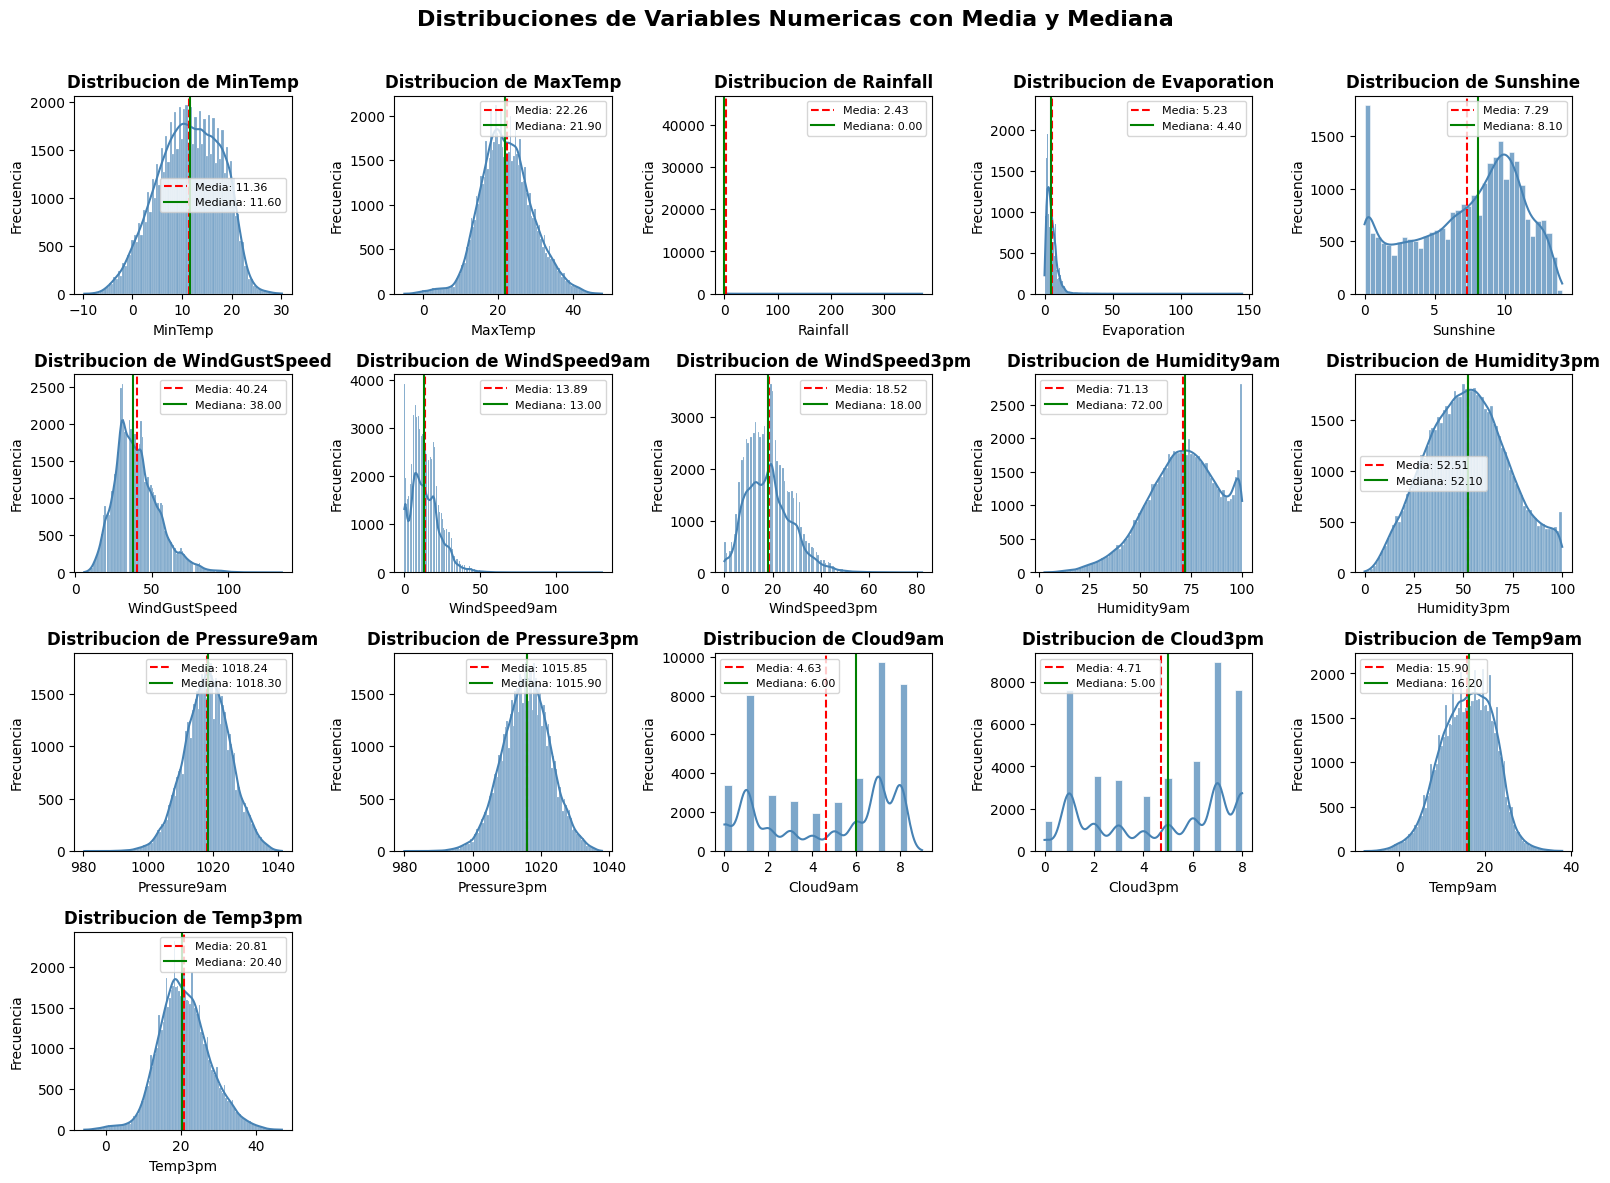

In [17]:
fig, axes = plt.subplots(5, 5, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretación

Temperaturas

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") presentan medias y medianas muy similares, lo que indica

distribuciones aproximadamente simétricas. El sesgo cercano a cero confirma esta simetría, mientras que la curtosis ligeramente

 negativa indica distribuciones sin colas extremas.

Además, el coeficiente de variación es moderado (30%–50%), lo que refleja una variabilidad esperable en este tipo de mediciones.

Se trata de variables estables y bien comportadas.


Rainfall

La variable "Rainfall" presenta una gran diferencia entre la media (2.36) y la mediana (0), lo que indica una fuerte asimetría.

El coeficiente de variación es extremadamente alto (359%), y el sesgo (9.83) junto con la curtosis (178) confirman una distribución

altamente sesgada con valores extremos.

Esto refleja que la mayoría de los días no llueve, pero cuando ocurre esto, puede haber precipitaciones muy intensas.

Se trata de una variable con alta variabilidad y presencia de outliers.


Evaporation y Sunshine

Las variables "Evaporation" y "Sunshine" presentan cierta asimetría, especialmente "Evaporation", donde la media es mayor que la

mediana y el sesgo es elevado.

El coeficiente de variación en ambas variables es relativamente alto, indicando una variabilidad considerable.

Tambien, "Evaporation" muestra una curtosis alta, lo que sugiere la presencia de valores extremos.


Viento

Las variables de viento ("WindGustSpeed", "WindSpeed9am", "WindSpeed3pm") presentan un sesgo positivo moderado, lo que indica que

existen algunos valores altos poco frecuentes.

Las medias son ligeramente superiores a las medianas, lo cual refuerza esta asimetría.

El coeficiente de variación es moderado a alto, reflejando variabilidad en la intensidad del viento.

Esto es consistente con la presencia ocasional de ráfagas fuertes.


Humedad

Las variables de humedad ("Humidity9am", "Humidity3pm") presentan medias y medianas muy cercanas, lo que indica distribuciones

simétricas.

El sesgo es cercano a cero y la curtosis indica ausencia de colas extremas.

El coeficiente de variación es moderado, lo que sugiere una variabilidad normal en las condiciones de humedad.


Presión

Las variables de presión ("Pressure9am", "Pressure3pm") presentan medias y medianas prácticamente iguales, indicando distribuciones

altamente simétricas.

El coeficiente de variación es muy bajo (<1%), lo que muestra una gran estabilidad en estas mediciones.

El sesgo y la curtosis cercanos a cero refuerzan que son variables bien distribuidas y sin valores extremos.


Nubosidad

Las variables "Cloud9am" y "Cloud3pm" presentan medias cercanas a la mediana, aunque con leve asimetría negativa.

El coeficiente de variación es alto, lo que indica dispersión en los niveles de nubosidad.

La curtosis negativa sugiere distribuciones más planas, sin concentración fuerte en valores centrales.

Cabe destacar que estas variables son discretas (valores entre 0 y 9).



En general, se observa que variables como temperatura y presión presentan comportamientos estables y simétricos, mientras que

variables como "Rainfall" y "Evaporation" muestran alta variabilidad y asimetría, lo cual es consistente con fenómenos climáticos

reales.

Estas diferencias serán relevantes al momento de aplicar técnicas de preprocesamiento y modelado.

### Distribución de Variables Categóricas

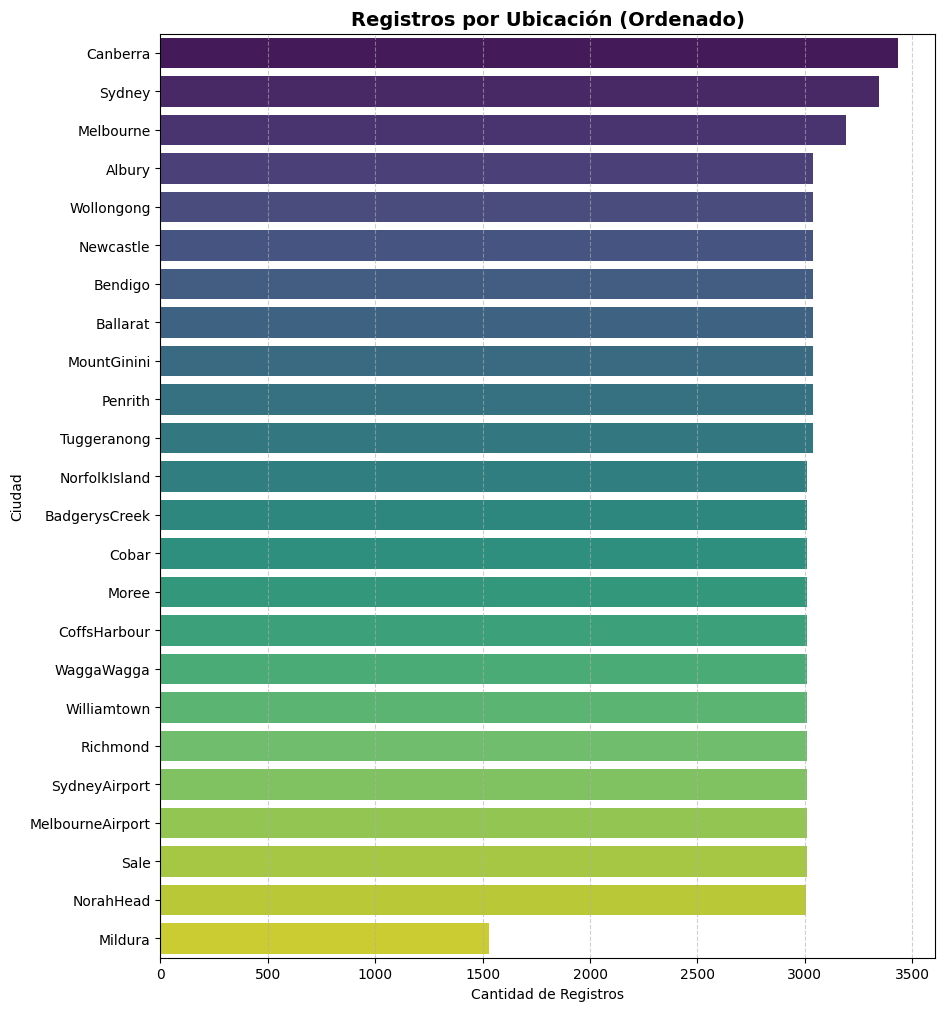

In [18]:
plt.figure(figsize=(10, 12))

# Location en eje Y
sns.countplot(y='Location', data=df, palette='viridis',
              order=df['Location'].value_counts().index)

plt.title('Registros por Ubicación (Ordenado)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

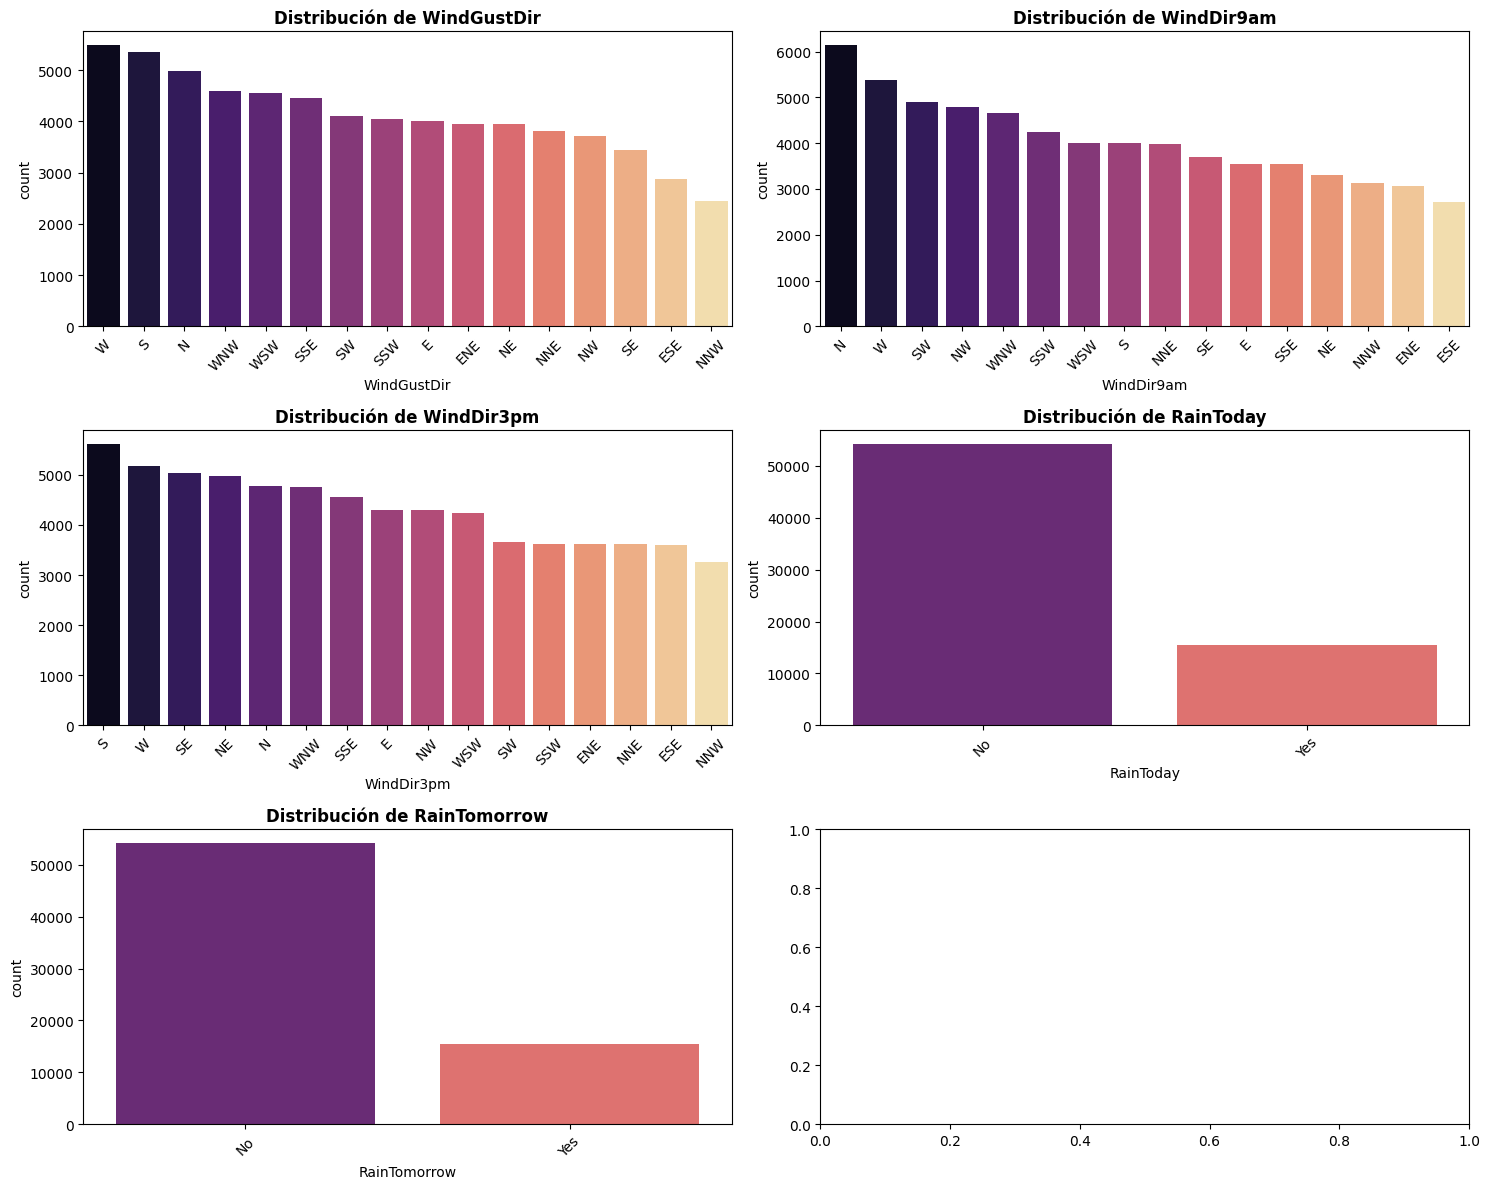

In [19]:
# Lista sin location
cols_sin_location = [col for col in cols_categoricas if col != 'Location']

# Crea el lienzo
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_sin_location):
    # Cuenta
    sns.countplot(x=col, data=df, ax=axes[i], palette='magma',
                  order=df[col].value_counts().index)

    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Interpretación de variables categóricas

Los gráficos muestran la distribución de las variables categóricas relacionadas con la dirección del viento y la presencia de lluvia.

Dirección del viento

Las variables "WindGustDir", "WindDir9am" y "WindDir3pm" presentan distribuciones relativamente equilibradas entre las distintas direcciones del viento.

Aunque aparecen con mayor frecuencia:
- En "WindGustDir" las direcciones "W" y "SE".
- En "WindDir9am" la dirección "N".
- En "WindDir3pm" las direcciones "SE" y "W".

Esto indica que ciertas direcciones del viento son más comunes en las ciudades analizadas.



RainToday

La variable "RainToday" muestra mayoría de la categoría "No".

Esto nos indica que en la mayoría de los días registrados, no hubo lluvia.



RainTomorrow

La variable objetivo "RainTomorrow" también presenta una mayoría de casos "No" respecto a "Yes".

Esto sugiere que el dataset se encuentra desbalanceado, ya que los días sin lluvia son considerablemente más frecuentes que los días con lluvia.

Este desbalance deberá tenerse en cuenta durante el entrenamiento y evaluación de los modelos de clasificación.

# Prueba de Normalidad

### Test D'Agostino-Pearson

In [20]:
from scipy import stats

ALPHA = 0.05
resultados = []

for col in cols_numericas:
    # Quitamos nulos solo para el test
    datos = df[col].dropna()

    # D'Agostino-Pearson
    stat, p_val = stats.normaltest(datos)

    resultados.append({
        'Variable': col,
        'Estadístico K2': f"{stat:.2f}",
        'p-valor': f"{p_val:.4f}",
        '¿Es Normal?': 'Si' if p_val > ALPHA else 'No'
    })

df_normalidad = pd.DataFrame(resultados)
print(df_normalidad)

         Variable Estadístico K2 p-valor ¿Es Normal?
0         MinTemp        2421.10  0.0000          No
1         MaxTemp         445.68  0.0000          No
2        Rainfall      103634.74  0.0000          No
3     Evaporation       34358.86  0.0000          No
4        Sunshine        5073.81  0.0000          No
5   WindGustSpeed        7097.90  0.0000          No
6    WindSpeed9am        9606.35  0.0000          No
7    WindSpeed3pm        5128.16  0.0000          No
8     Humidity9am        1980.37  0.0000          No
9     Humidity3pm        1694.25  0.0000          No
10    Pressure9am         114.64  0.0000          No
11    Pressure3pm          74.91  0.0000          No
12       Cloud9am      247300.49  0.0000          No
13       Cloud3pm      315529.51  0.0000          No
14        Temp9am         529.57  0.0000          No
15        Temp3pm         603.39  0.0000          No


Optamos por el test de D'Agostino-Pearson porque combina el sesgo y la curtosis. Como el análisis descriptivo ya mostraba valores altos de curtosis en variables como Rainfall, este test valida formalmente de que no se puede asumir una distribución Gaussiana.

Al confirmar que ninguna variable es normal (p-valor < 0.05), justificamos técnicamente que en el preprocesamiento usaremos RobustScaler y para las correlaciones es preferible usar el coeficiente de Spearman sobre el de Pearson.

### QQPLOTS

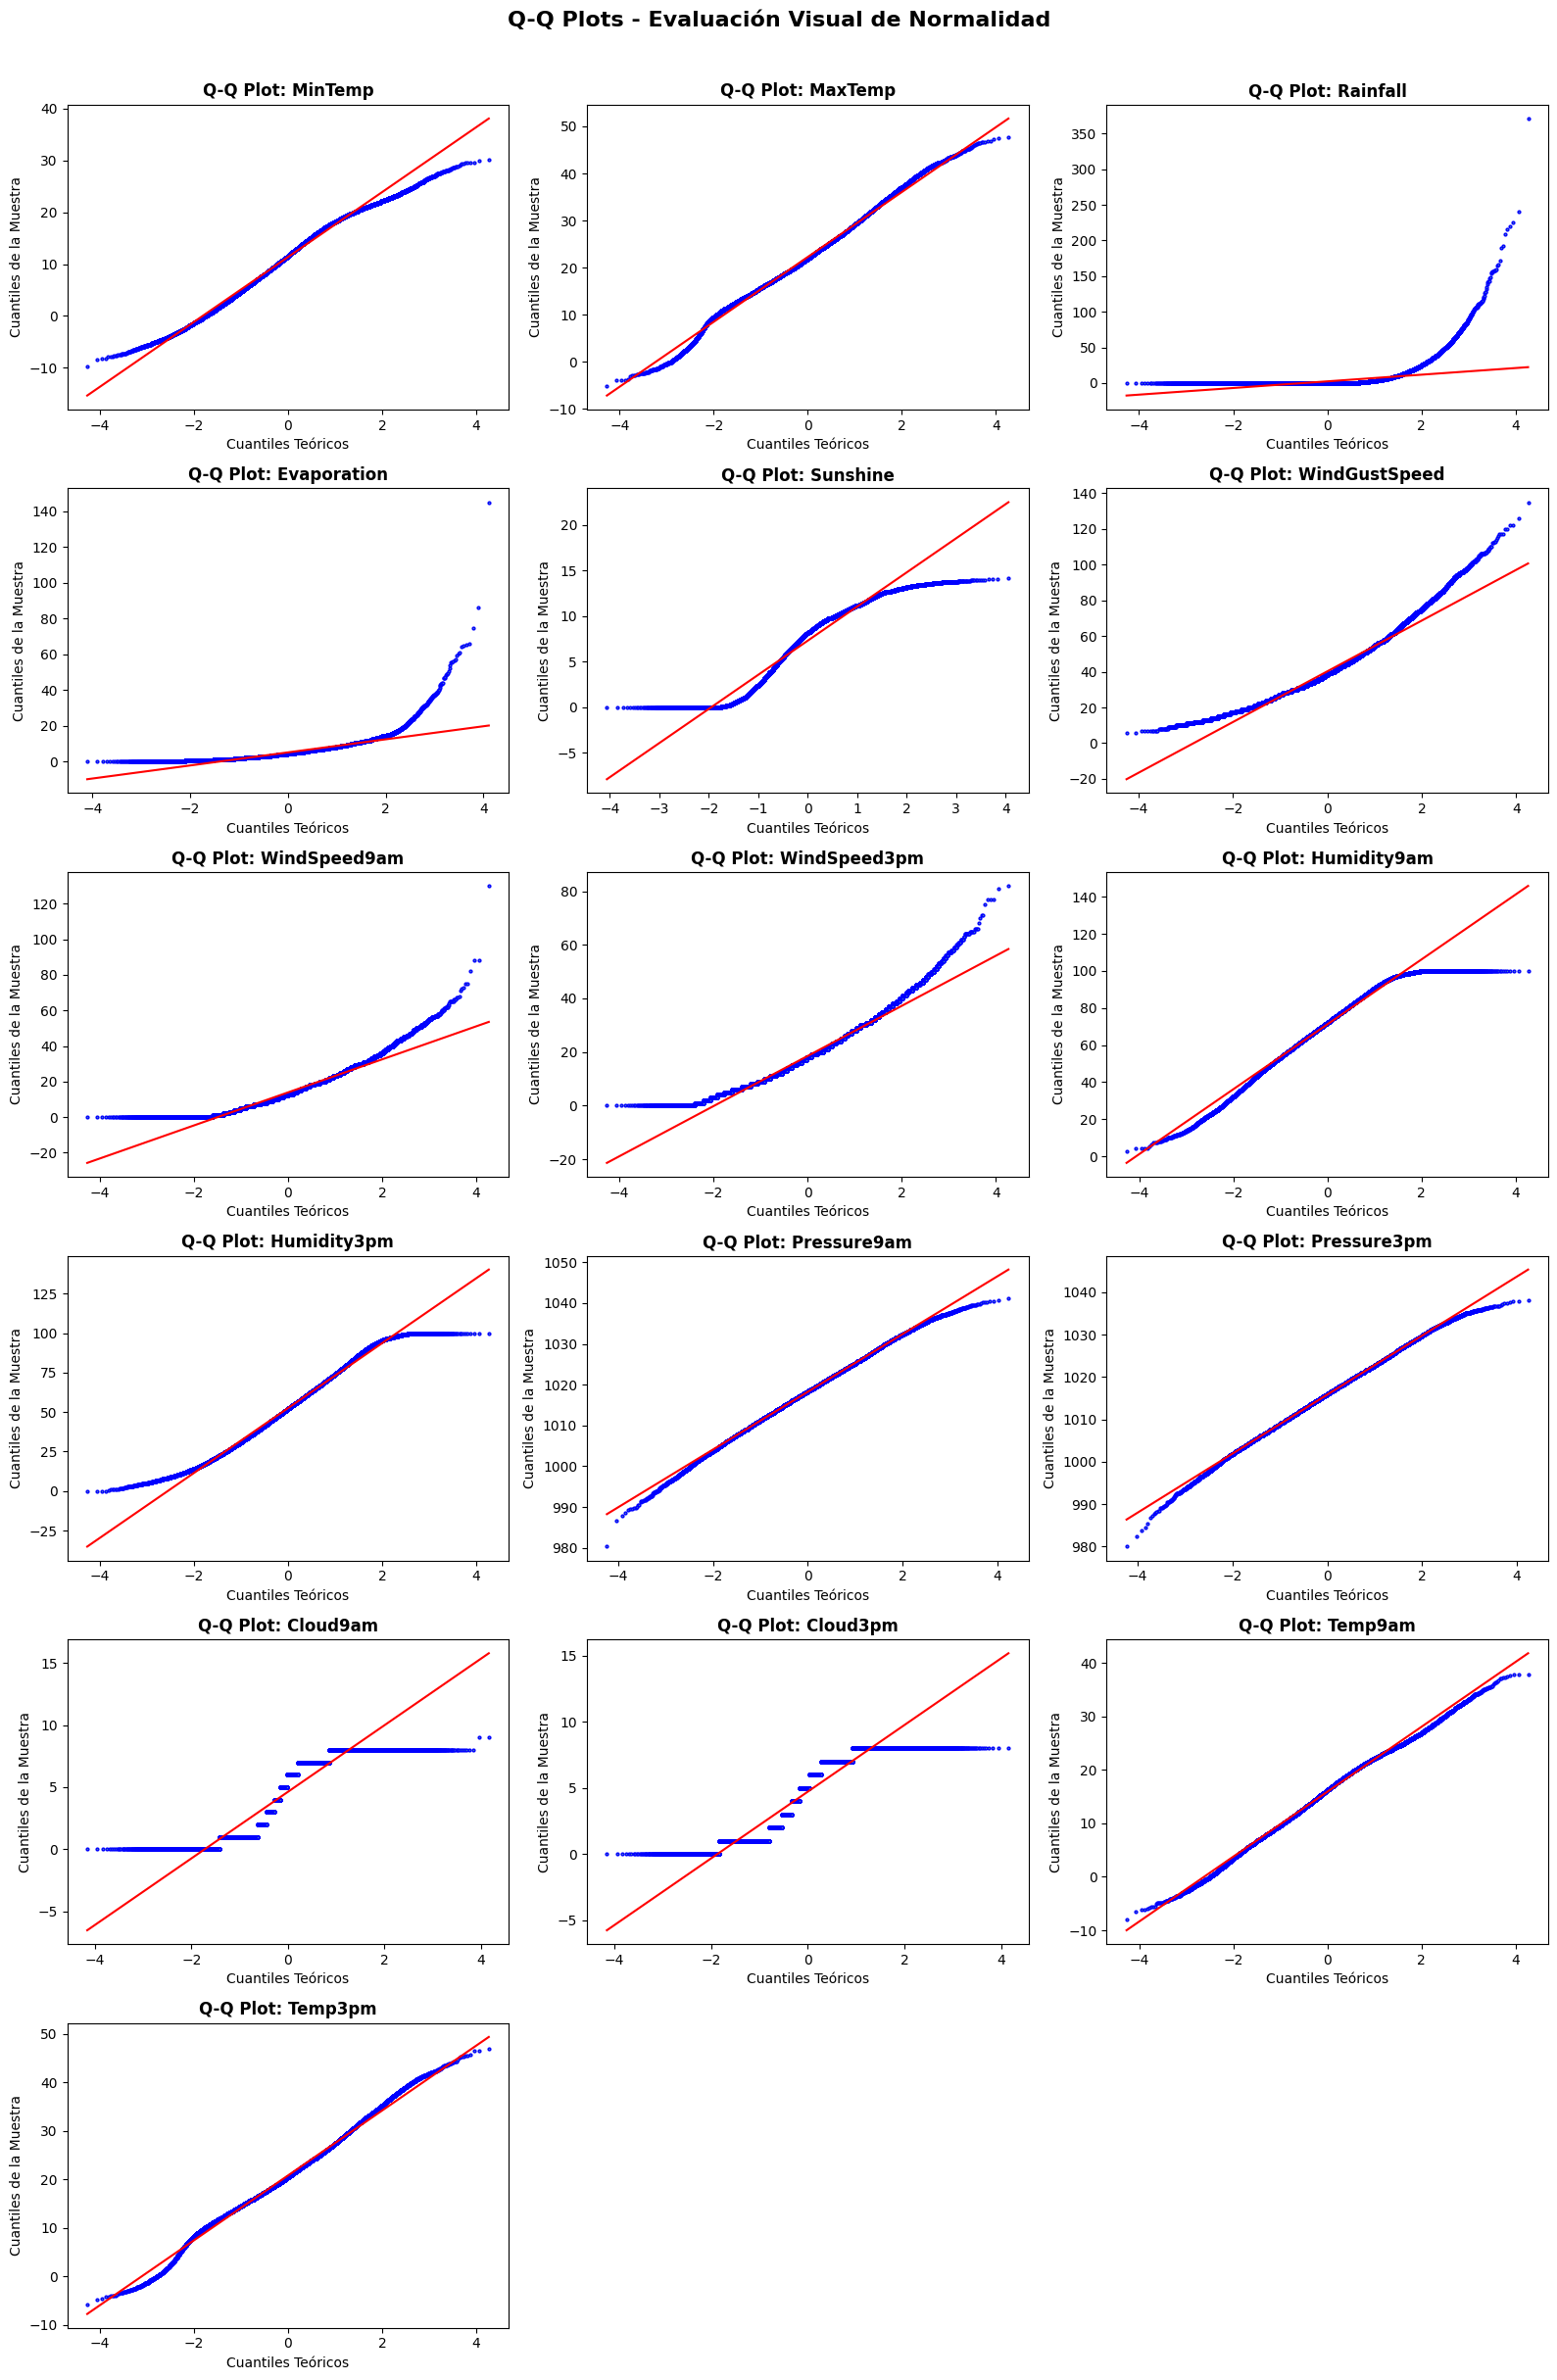

In [21]:
# Calculamos 3 columnas
n_cols = 3
n_rows = math.ceil(len(cols_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    # quitamos nulos temporalmente
    datos = df[col].dropna()

    # Gráfico Q-Q
    stats.probplot(datos, dist='norm', plot=ax)


    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue') # Puntos
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red') # Línea de referencia
    ax.set_xlabel('Cuantiles Teóricos')
    ax.set_ylabel('Cuantiles de la Muestra')

# Desactivamos cuadros sobrantes
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluación Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") y presión ("Pressure9am", "Pressure3pm") muestran una distribución

aproximadamente normal, los puntos siguen relativamente bien la línea de referencia.

Las variables como "Rainfall", "Evaporation" y las velocidades de viento presentan fuertes desviaciones respecto de la línea roja, indicando distribuciones

asimétricas y presencia de valores extremos.

Las variables "Cloud9am" y "Cloud3pm" muestran patrones escalonados debido a que son variables discretas.

Las variables de Humedad presentan una distribución parcialmente simétrica, aunque con desviaciones en los extremos.

En general, observamos que no todas las variables siguen una distribución normal, especialmente aquellas relacionadas con fenómenos climáticos extremos

como lluvia y viento.

# Gestion de datos: Nulos, Duplicados, Consistencia

### Registros Nulos

In [22]:
# Verificamos si hay filas nulas
df.isna().all(axis=1).any()

np.False_

In [23]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
               Nulos  Porcentaje (%)            Tipo
Date               0        0.000000  datetime64[ns]
Location           0        0.000000          object
MinTemp         1099        1.528491         float64
MaxTemp          931        1.294836         float64
Rainfall        2214        3.079234         float64
Evaporation    37125       51.633496         float64
Sunshine       43928       61.095117         float64
WindGustDir     6092        8.472761          object
WindGustSpeed   6084        8.461635         float64
WindDir9am      6796        9.451885          object
WindDir3pm      2788        3.877554          object
WindSpeed9am    1373        1.909570         float64
WindSpeed3pm    1987        2.763522         float64
Humidity9am     1765        2.454764         float64
Humidity3pm     2227        3.097314         float64
Pressure9am    10570       14.700769         float64
Pressure3pm    10518       14.628447         float64
Cloud9am       28403

In [24]:
col_nulos = pct_nulos[pct_nulos>0].sort_values(ascending=False)

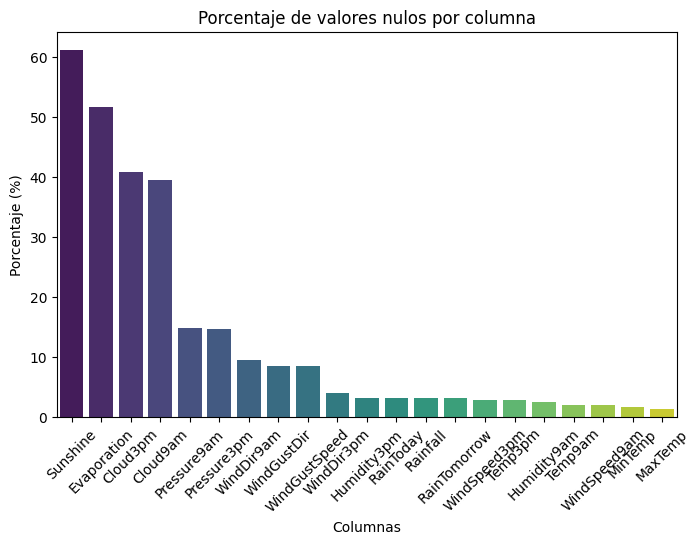

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Patrones de datos faltantes

Podemos observar que las variables con mas datos nulos son Sunshine, Evaporation, Cloud3pm y Cloud9am con mas del 35%.

No parecería un patrón completamente aleatorio (MCAR), ya que la cantidad de datos faltantes es muy alta. Se consideraría más

razonable asumir los datos faltantes del tipo MAR (Missing At Random), donde la ausencia de datos puede depender de otras variables

observadas del dataset, como la ubicación ("Location") o la fecha ("Date").

Se evaluarán estrategias de imputación adecuadas segun el tipo de variable y el porcentaje de datos faltantes.



### Registros duplicados

In [26]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: En datos meteorológicos, cada registro representa una observación única \n'
          'en Ubicación/Fecha. La existencia de filas exactamente iguales \n'
          'indica una redundancia de datos o errores en la \n'
          'consolidación del dataset, y no eventos atmosféricos independientes.')
else:
    print('No se detectaron registros duplicados. La integridad temporal y espacial es correcta.')

Registros duplicados: 0 (0.00%)

No se detectaron registros duplicados. La integridad temporal y espacial es correcta.


### Registros inconsistentes

In [27]:
# Definimos las reglas lógicas
error_temp    = df['MinTemp'] > df['MaxTemp']
error_lluvia  = df['Rainfall'] < 0
error_humedad = (df['Humidity9am'] > 100) | (df['Humidity3pm'] > 100)
error_viento  = (df['WindGustSpeed'] < 0) | (df['WindSpeed9am'] < 0) | (df['WindSpeed3pm'] < 0)

# Aplicamos el reemplazo por NaN columna por columna
df.loc[error_temp, ['MinTemp', 'MaxTemp']] = np.nan
df.loc[error_lluvia, 'Rainfall'] = np.nan
df.loc[df['Humidity9am'] > 100, 'Humidity9am'] = np.nan
df.loc[df['Humidity3pm'] > 100, 'Humidity3pm'] = np.nan
df.loc[df['WindGustSpeed'] < 0, 'WindGustSpeed'] = np.nan
df.loc[df['WindSpeed9am'] < 0, 'WindSpeed9am'] = np.nan
df.loc[df['WindSpeed3pm'] < 0, 'WindSpeed3pm'] = np.nan

# Auditamos las columnas
cols_audit = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
              'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

print(f'\nNuevos nulos:')
print(df[cols_audit].isnull().sum().to_dict())

print("\nDECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN "
      "para ser reparados en la etapa de imputación.")


Nuevos nulos:
{'MinTemp': 1148, 'MaxTemp': 980, 'Rainfall': 2214, 'Humidity9am': 1765, 'Humidity3pm': 2227, 'WindGustSpeed': 6084, 'WindSpeed9am': 1373, 'WindSpeed3pm': 1987}

DECISIÓN: No se eliminaron filas. Los datos erróneos o repetidos se marcaron como NaN para ser reparados en la etapa de imputación.


# Análisis de Balanceo de Clases

In [28]:
# Analizamos el Target
target = 'RainTomorrow'
conteo = df[target].value_counts()
ir = conteo.max() / conteo.min()

print(f'DIAGNÓSTICO DEL TARGET: {target}')
print('=' * 40)
print(f'Clase mayoritaria (No llueve): {conteo.max()}')
print(f'Clase minoritaria (Sí llueve): {conteo.min()}')
print(f'Imbalance Ratio (IR): {ir:.2f}')

# Criterios de decisión
if ir > 5:
    status = "ALTO"
elif ir > 2.5:
    status = "MODERADO"
else:
    status = "ACEPTABLE"

print(f'Resultado: Desbalanceo {status}')
print('=' * 40)

DIAGNÓSTICO DEL TARGET: RainTomorrow
Clase mayoritaria (No llueve): 54165
Clase minoritaria (Sí llueve): 15522
Imbalance Ratio (IR): 3.49
Resultado: Desbalanceo MODERADO


Interpretación: Por cada día que llueve (Yes), hay aproximadamente 3.5 días en los que no llueve (No).

In [29]:
for col in cols_categoricas:
    conteo = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    clase_mayor = conteo.idxmax()
    clase_menor = conteo.idxmin()
    ir = conteo.max() / conteo.min()

    print(f'Variable: {col}')
    print('-' * 40)

    for cat in conteo.index:
        print(f'  {str(cat):>12s}: {conteo[cat]:>6d} ({pct[cat]:.2f}%)')

    print(f'  Clase mayoritaria: {clase_mayor} ({conteo.max()})')
    print(f'  Clase minoritaria: {clase_menor} ({conteo.min()})')
    print(f'  Imbalance Ratio (IR): {ir:.2f}')

    if ir > 5:
        print(f'  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.')
    elif ir > 2.5:
        print(f'  >> ATENCION: Desbalanceo moderado (IR > 2.5).')
    else:
        print(f'  >> Balanceo aceptable.')
    print()

Variable: Location
----------------------------------------
      Canberra:   3435 (4.78%)
        Sydney:   3343 (4.65%)
     Melbourne:   3192 (4.44%)
        Albury:   3039 (4.23%)
    Wollongong:   3039 (4.23%)
     Newcastle:   3039 (4.23%)
       Bendigo:   3039 (4.23%)
      Ballarat:   3039 (4.23%)
   MountGinini:   3039 (4.23%)
       Penrith:   3038 (4.23%)
   Tuggeranong:   3038 (4.23%)
  NorfolkIsland:   3008 (4.18%)
  BadgerysCreek:   3008 (4.18%)
         Cobar:   3008 (4.18%)
         Moree:   3008 (4.18%)
  CoffsHarbour:   3008 (4.18%)
    WaggaWagga:   3008 (4.18%)
   Williamtown:   3008 (4.18%)
      Richmond:   3008 (4.18%)
  SydneyAirport:   3008 (4.18%)
  MelbourneAirport:   3008 (4.18%)
          Sale:   3008 (4.18%)
     NorahHead:   3003 (4.18%)
       Mildura:   1530 (2.13%)
  Clase mayoritaria: Canberra (3435)
  Clase minoritaria: Mildura (1530)
  Imbalance Ratio (IR): 2.25
  >> Balanceo aceptable.

Variable: WindGustDir
---------------------------------------

Las variables Location y Direcciones del Viento tienen un Balanceo Aceptable (IR entre 1.51 y 2.18).

Location (IR 2.18): La mayoría de las ciudades representan aprox. 2% del dataset. Tambien observamos que Nhil, Katherine y Uluru tienen la mitad de

registros (aprox. 1%) que las ciudades principales. Esto sugiere que esas estaciones meteorológicas fueron instaladas más tarde o reportaron datos por

menos tiempo.

Direcciones del Viento (IR ~1.6): Las direcciones están muy bien repartidas. No hay un viento que predomine de forma masiva sobre los demás, lo cual es

ideal para que el modelo aprenda la influencia de todas las direcciones por igual.

La Simetría entre RainToday y RainTomorrow es de IR (3.46) y porcentajes casi idénticos (77.58%). Esto indica una consistencia muy alta en el

dataset. La probabilidad de que llueva "hoy" es la misma que la de "mañana" estadísticamente, lo que confirma que estamos ante un fenómeno climático

estable en el tiempo.

# Análisis de Correlaciones y Colinealidad

Utilizaremos el Spearman por:

Falta de Normalidad: las pruebas de  D'Agostino-Pearson rechazaron la hipótesis nula de normalidad (p < 0.05) para todas las variables numéricas.

Presencia de Outliers Extremos: Variables como Rainfall mostraron una curtosis de +178.1, lo que indica "colas pesadas" o valores muy extremos (outliers).

Spearman es mucho más robusto ante outliers porque trabaja con rangos en lugar de valores exactos.

Relaciones No Lineales: En meteorología, muchas relaciones son monótonas (cuando una sube, la otra también) pero no necesariamente en línea recta. Spearman

captura estas relaciones que Pearson ignoraría o subestimaría.

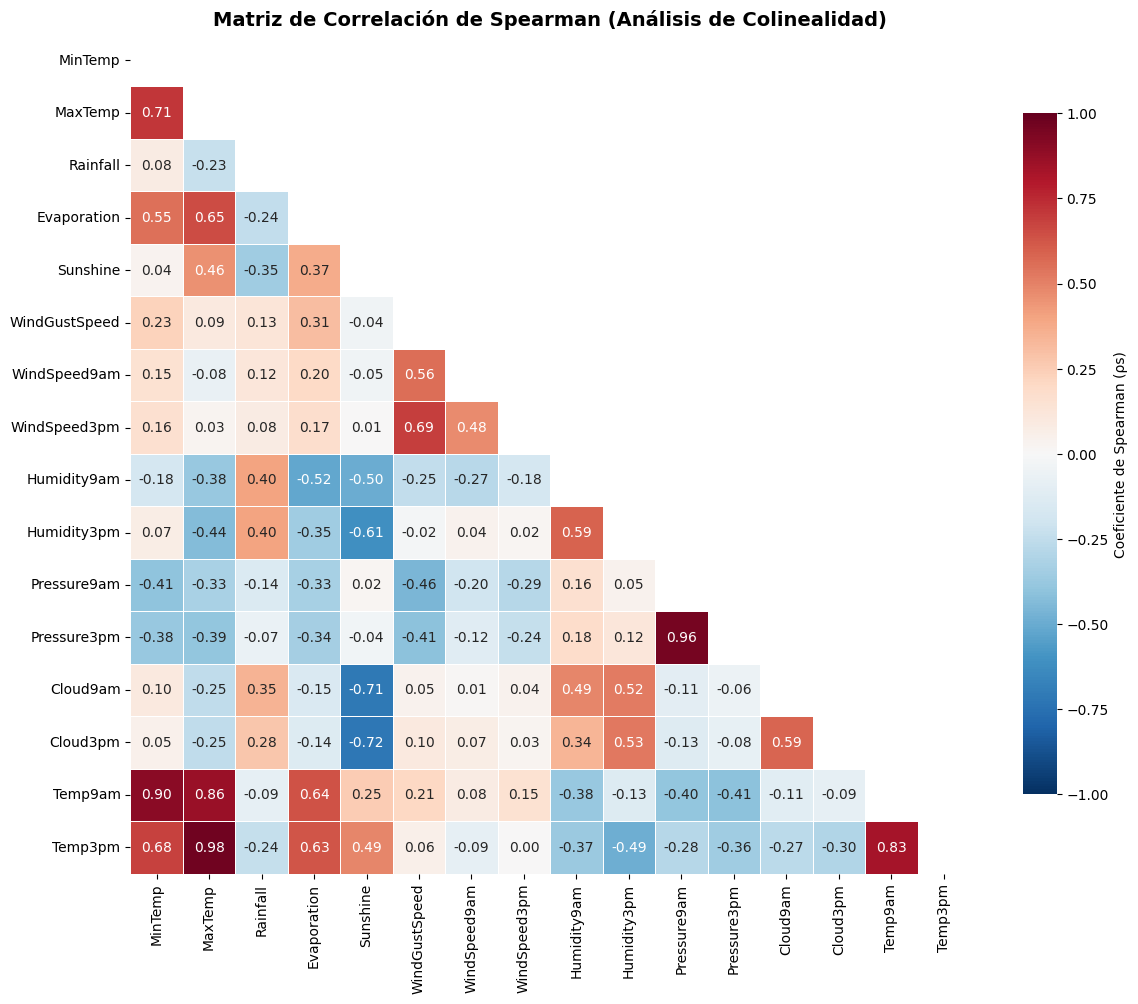

In [30]:
#  Calculamos la matriz usando Spearman
corr_spearman = df[cols_numericas].corr(method='spearman')

#  Máscara triangular
# np.triu crea una matriz de unos en la parte superior y la usamos para "tapar"
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman (ρs)'})

ax.set_title('Matriz de Correlación de Spearman (Análisis de Colinealidad)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se observan correlaciones positivas altas entre variables relacionadas con temperatura:

"MaxTemp" y "Temp3pm" (0.98)
"MinTemp" y "Temp9am" (0.89)
"Temp9am" y "MaxTemp" (0.89)

Esto indica que estas variables contienen información muy similar.

También se observan correlaciones negativas entre humedad y temperatura, lo que sugiere que a mayor temperatura suele disminuir la humedad relativa.

Por otro lado, las variables de presión ("Pressure9am" y "Pressure3pm") presentan una correlación extremadamente alta (0.96), indicando una fuerte relación

entre ambas mediciones.

En general, las correlaciones observadas son coherentes con el comportamiento esperado de variables meteorológicas.

In [31]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |Spearman| >= {UMBRAL_COLINEALIDAD} (Colinealidad detectada):')
print('=' * 65)

pares_colineales = []

for i in range(len(corr_spearman.columns)):
    for j in range(i + 1, len(corr_spearman.columns)):
        r = corr_spearman.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_spearman.columns[i]
            var2 = corr_spearman.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: ρs = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).')
    print('Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.')

Pares con |Spearman| >= 0.85 (Colinealidad detectada):
  MinTemp <-> Temp9am: ρs = 0.8995
  MaxTemp <-> Temp9am: ρs = 0.8632
  MaxTemp <-> Temp3pm: ρs = 0.9759
  Pressure9am <-> Pressure3pm: ρs = 0.9591

Se detectaron 4 par(es) colineal(es).
Decisión: Estas variables son redundantes. Evaluaremos eliminar o usar PCA.


### VIF

In [32]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

   Temp3pm: VIF =      30.97  << SEVERA
   MaxTemp: VIF =      26.54  << SEVERA
  Pressure9am: VIF =      17.71  << SEVERA
  Pressure3pm: VIF =      17.45  << SEVERA
   Temp9am: VIF =      16.66  << SEVERA
   MinTemp: VIF =       8.31  << MODERADA
  Humidity3pm: VIF =       5.57  << MODERADA
  Sunshine: VIF =       3.65
  Humidity9am: VIF =       3.53
  WindGustSpeed: VIF =       3.05
  WindSpeed3pm: VIF =       2.25
  Cloud9am: VIF =       2.24
  Cloud3pm: VIF =       2.20
  Evaporation: VIF =       1.94
  WindSpeed9am: VIF =       1.81
  Rainfall: VIF =       1.17


Colinealidad Severa (VIF > 10). Significa que estas variables están "explicadas" por las demás y son redundantes para el aprendizaje del modelo.


Temp3pm, MaxTemp, Temp9am: Presentan los valores más altos (VIF entre 20 y 38). Estas medidas estadísticamente están altamente correlacionadas entre sí.

Pressure3pm, Pressure9am: Ambos tienen un VIF de aproximadamente 18.5. Son variables "espejo" que aportan información redundante.

### Eliminación de variables

Se decide conservar únicamente MaxTemp. Esta variable presenta el menor índice de nulos (0.86%) en comparación con Temp3pm (2.48%) y Temp9am (1.21%).

También, MaxTemp es un indicador robusto del calor máximo diario.

Se conserva Pressure3pm y se elimina Pressure9am porque ambas tienen VIFs casi idénticos (aprox. 18.5), pero Pressure3pm es cronológicamente más cercana al

momento de la predicción (23:59hs), aportando información más fresca sobre el estado de la atmósfera antes del día siguiente.

In [33]:
# Eliminamos (Nulos > 40% y patrón MAR)
cols_baja_integridad = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
df = df.drop(columns=cols_baja_integridad)

# Eliminamos por Colinealidad Severa (VIF > 10)
cols_colineales = ['Temp3pm', 'Temp9am', 'Pressure9am']
df = df.drop(columns=cols_colineales)

# Actualizamos variables numéricas
cols_numericas = [c for c in cols_numericas if c not in (cols_baja_integridad + cols_colineales)]

print(f"Columnas eliminadas por integridad: {cols_baja_integridad}")
print(f"Columnas eliminadas por colinealidad: {cols_colineales}")

Columnas eliminadas por integridad: ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
Columnas eliminadas por colinealidad: ['Temp3pm', 'Temp9am', 'Pressure9am']


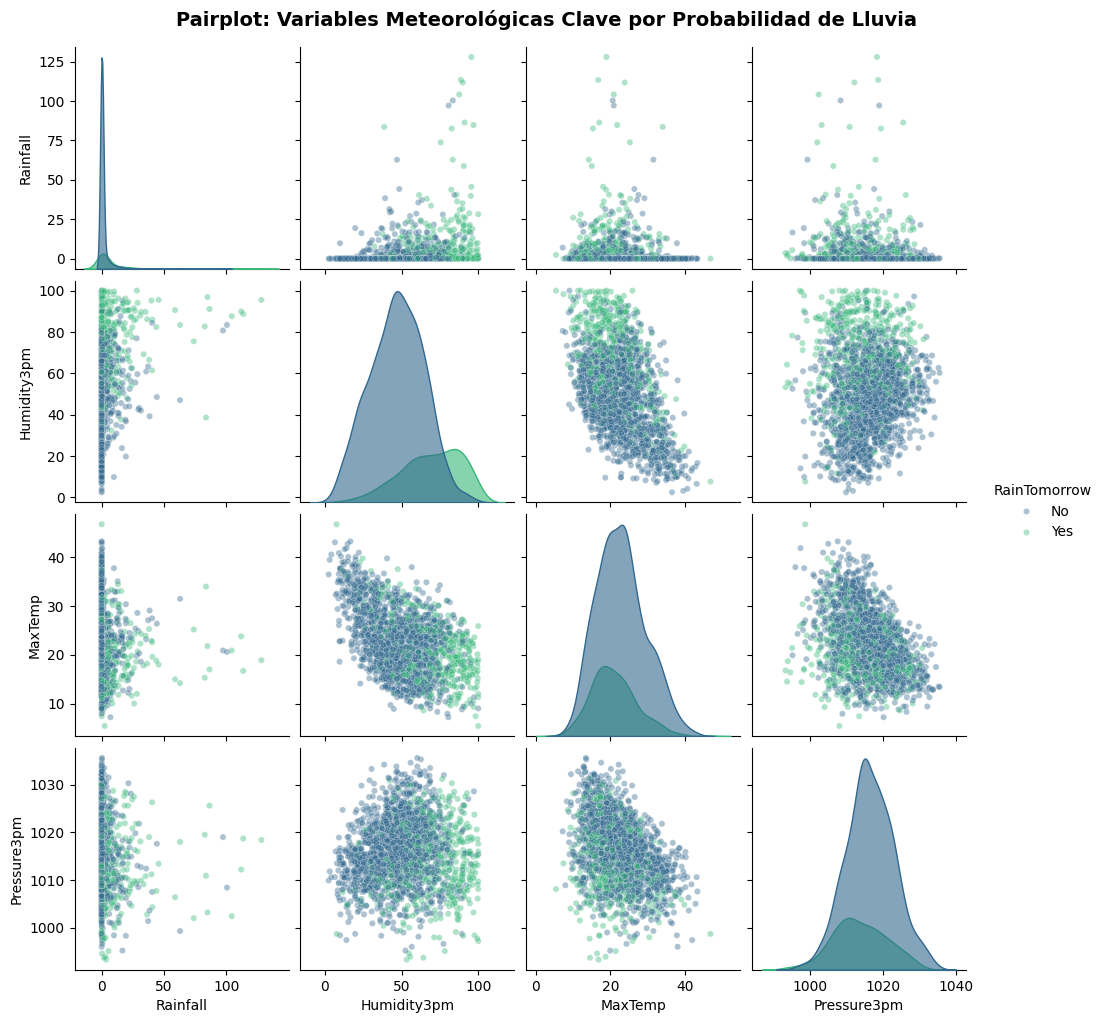

In [34]:
#  Variables basadas en el análisis de VIF
vars_analisis = ['Rainfall', 'Humidity3pm', 'MaxTemp', 'Pressure3pm']
target = 'RainTomorrow'

#  Pairplot
# Usamos una muestra
g = sns.pairplot(df[vars_analisis + [target]].dropna().sample(2000, random_state=42),
                 hue=target,
                 palette='viridis',
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kws={'alpha': 0.6})

# Visualización
g.figure.suptitle('Pairplot: Variables Meteorológicas Clave por Probabilidad de Lluvia',
                  fontsize=14, fontweight='bold', y=1.02)

plt.show()

Se observa que los casos donde sí llueve ("Yes") suelen estar asociados con:
- mayores valores de "Rainfall"
- mayor humedad ("Humidity3pm")
- menores valores de presión ("Pressure3pm")
- temperaturas máximas más bajas ("MaxTemp")

También, se identifican relaciones inversas entre algunas variables, por ejemplo:
- a mayor temperatura máxima, menor humedad
- a mayor presión, menor probabilidad de lluvia

En general, las variables seleccionadas muestran patrones diferenciados entre días con lluvia y sin lluvia, lo que indica que podrían ser útiles para los modelos de clasificación.

# Detección de Outliers

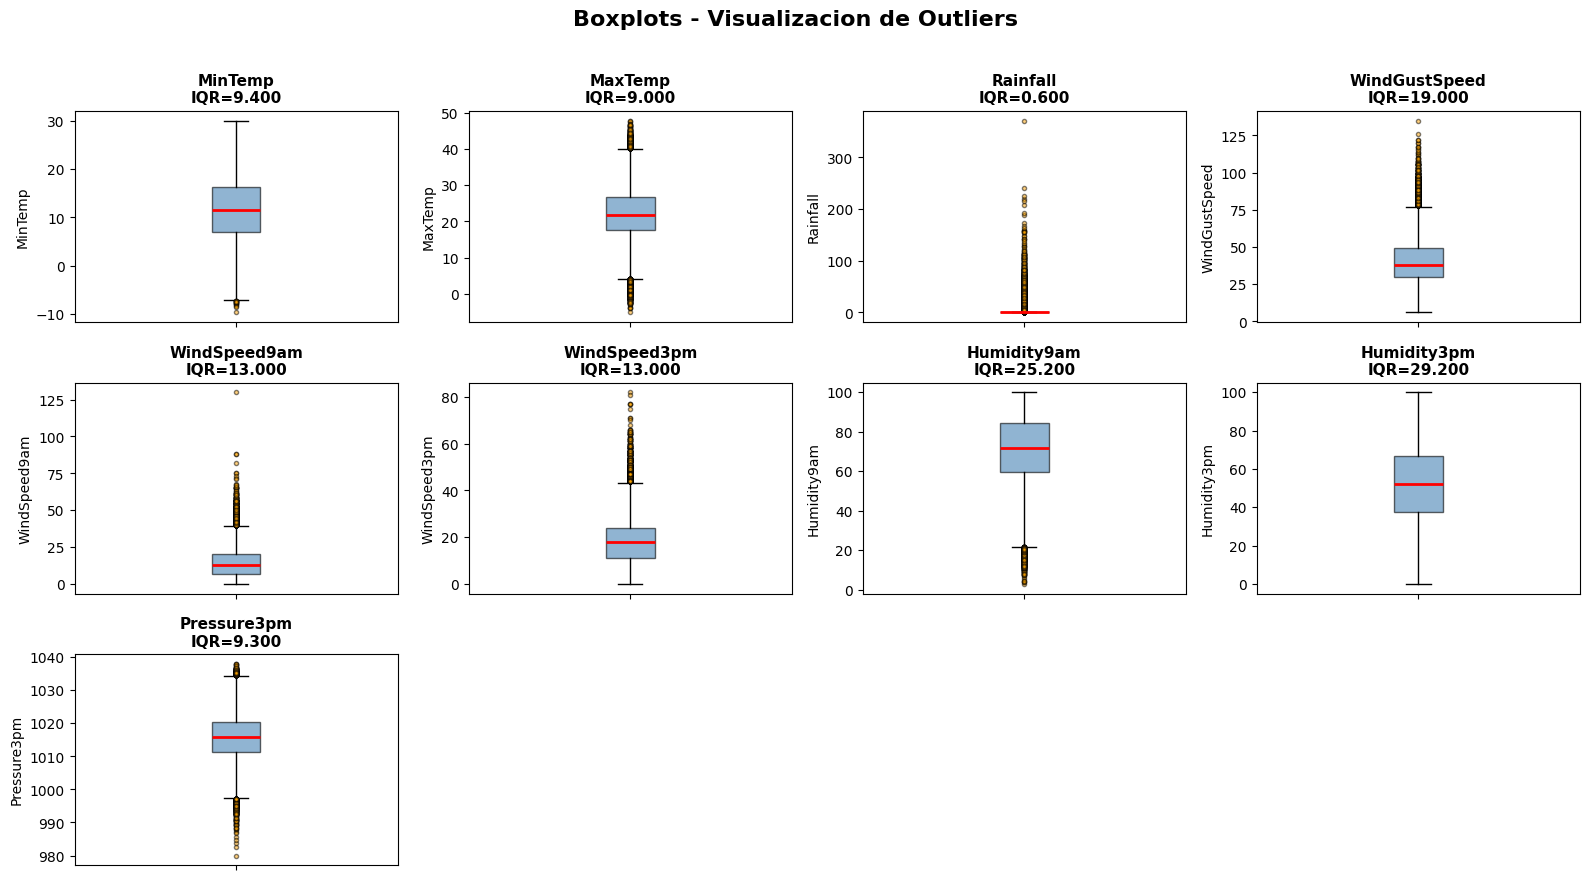

In [35]:
fig, axes = plt.subplots(5, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se observa que variables "Rainfall", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm" presentan una gran cantidad de outliers y

distribuciones asimétricas, especialmente hacia valores altos.

Se observa que variables como "MinTemp", "MaxTemp", "Pressure3pm" muestran distribuciones más estables y con menor cantidad de valores extremos.

En general, los outliers observados son coherentes con fenómenos meteorológicos extremos y no necesariamente representan errores en los datos.

# División Train-Test

In [36]:
df = df.dropna(subset=['RainTomorrow'])

# Definimos X e y
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Feature Engineering

Creamos la variable 'Season' adaptada al hemisferio sur para capturar la estacionalidad australiana, y variables de interacción como el 'TempRange' y

'HumDiff'. Estas son fundamentales porque el gradiente de humedad y la amplitud térmica diaria son indicadores físicos de inestabilidad atmosférica mucho

más potentes que las mediciones aisladas de la mañana o la tarde.

In [37]:
# funcion
def aplicar_ingenieria_variables(df):

    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month

    # Mapeo según el hemisferio sur
    season_map = {
        12: 'Summer', 1: 'Summer', 2: 'Summer',
        3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
        6: 'Winter', 7: 'Winter', 8: 'Winter',
        9: 'Spring', 10: 'Spring', 11: 'Spring'
    }
    df['Season'] = df['Month'].map(season_map)

    # Variables de Amplitud térmica

    df['TempRange'] = df['MaxTemp'] - df['MinTemp']

    # Interacción de Humedad

    df['HumDiff'] = df['Humidity3pm'] - df['Humidity9am']

    # Diferencia de Presión

    if 'Pressure9am' in df.columns and 'Pressure3pm' in df.columns:
        df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']

    return df


X_train = aplicar_ingenieria_variables(X_train.copy())
X_test = aplicar_ingenieria_variables(X_test.copy())

# ACTUALIZACIÓN DE LISTAS

# Se agrega season
if 'Season' not in cols_categoricas:
    cols_categoricas.append('Season')

# Agregamos las nuevas numéricas
nuevas_num = ['TempRange', 'HumDiff', 'PressureDiff']
for col in nuevas_num:
    if col in X_train.columns and col not in cols_numericas:
        cols_numericas.append(col)

print("Feature Engineering exitoso.")
print(f"Columnas actuales: {X_train.shape[1]}")

Feature Engineering exitoso.
Columnas actuales: 19


In [38]:
# Variables para eliminar

cols_redundantes = ['Date', 'Month']

X_train = X_train.drop(columns=cols_redundantes)
X_test = X_test.drop(columns=cols_redundantes)

# Imputacion de datos

Descartamos el Z-Score debido a que nuestras pruebas de D'Agostino-Pearson confirmaron distribuciones no normales y variables con curtosis leptocúrtica extrema. Optamos por el Método IQR, ya que es un estadístico robusto que no se deja arrastrar por el sesgo

In [39]:

cols_numericas = [c for c in cols_numericas if c in X_train.columns]
cols_categoricas = [c for c in cols_categoricas if c in X_train.columns]


# IMPUTACIÓN DE VARIABLES NUMÉRICAS (Mediana)

for col in cols_numericas:
    # Calculamos el estadístico solo en Train para evitar Data Leakage
    mediana_train = X_train[col].median()

    # Aplicamos a ambos conjuntos
    X_train[col] = X_train[col].fillna(mediana_train)
    X_test[col] = X_test[col].fillna(mediana_train)

# IMPUTACIÓN DE VARIABLES CATEGÓRICAS (Moda)

for col in cols_categoricas:

    moda_train = X_train[col].mode()[0]

    # Aplicamos a ambos conjuntos
    X_train[col] = X_train[col].fillna(moda_train)
    X_test[col] = X_test[col].fillna(moda_train)

# AUDITORÍA

nulos_finales = X_train.isnull().sum().sum()
print(f"Imputación completada. Total de nulos remanentes en X_train: {nulos_finales}")
if nulos_finales == 0:
    print("Estado del dataset: INTEGRIDAD TOTAL (Listo para codificación y escalado)")

Imputación completada. Total de nulos remanentes en X_train: 0
Estado del dataset: INTEGRIDAD TOTAL (Listo para codificación y escalado)


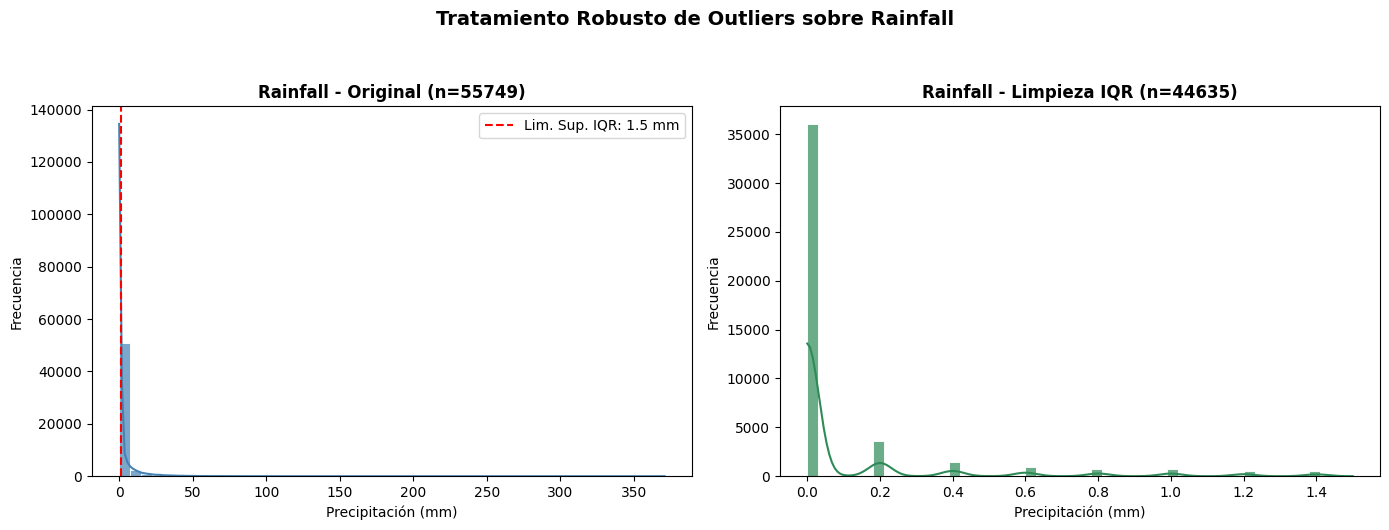

Análisis de Rainfall:
  - Registros considerados outliers: 11114
  - Porcentaje de limpieza: 19.94%


In [40]:
# Elegimos una columna con muchos outliers
col_ejemplo = 'Rainfall'
IQR_FACTOR = 1.5

# Tomamos datos sin nulos
datos = X_train[col_ejemplo]

# Cálculo de Límites Robustos (IQR)
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

# Filtrado para la visualización
datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Con Outliers
sns.histplot(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7, ax=axes[0], kde=True)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.1f} mm')
axes[0].set_title(f'{col_ejemplo} - Original (n={len(datos)})', fontweight='bold')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Gráfico 2: Sin Outliers (Efecto de la Limpieza)
sns.histplot(datos_sin_outliers, bins=50, color='seagreen', edgecolor='white', alpha=0.7, ax=axes[1], kde=True)
axes[1].set_title(f'{col_ejemplo} - Limpieza IQR (n={len(datos_sin_outliers)})', fontweight='bold')
axes[1].set_xlabel('Precipitación (mm)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Tratamiento Robusto de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Resumen
eliminados = len(datos) - len(datos_sin_outliers)
print(f'Análisis de {col_ejemplo}:')
print(f'  - Registros considerados outliers: {eliminados}')
print(f'  - Porcentaje de limpieza: {(eliminados / len(datos)) * 100:.2f}%')

Tomamos la decisión de no eliminar estos registros porque al hacerlo eliminaría la variabilidad más importante de nuestro target (los días de lluvia). En

su lugar, optamos por un RobustScaler, que utiliza la mediana y el rango intercuartílico para normalizar los datos, permitiendo que el modelo aprenda de

estos valores extremos sin que su magnitud distorsione los pesos del algoritmo de clasificación".

# Escalado

In [41]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[cols_numericas]),
    columns=cols_numericas,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[cols_numericas]),
    columns=cols_numericas,
    index=X_test.index
)

# Verificación técnica del escalado robusto
print('Verificación post-escalado Robusto (X_train):')
print('=' * 65)
verificacion = pd.DataFrame({
    'Mediana': X_train_scaled.median(),
    'IQR': X_train_scaled.quantile(0.75) - X_train_scaled.quantile(0.25),
    'Min': X_train_scaled.min(),
    'Max': X_train_scaled.max()
})
print(verificacion.round(3))

print('\nInterpretación: Mediana ≈ 0 e IQR ≈ 1. Los valores Max altos son outliers preservados.')

Verificación post-escalado Robusto (X_train):
               Mediana  IQR    Min      Max
MinTemp            0.0  1.0 -2.280    2.000
MaxTemp            0.0  1.0 -3.000    2.822
Rainfall           0.0  1.0  0.000  618.333
WindGustSpeed      0.0  1.0 -2.000    6.062
WindSpeed9am       0.0  1.0 -1.083    9.750
WindSpeed3pm       0.0  1.0 -1.500    5.333
Humidity9am        0.0  1.0 -2.753    1.134
Humidity3pm        0.0  1.0 -1.835    1.687
Pressure3pm        0.0  1.0 -4.675    2.857
TempRange          0.0  1.0 -1.400    2.680
HumDiff            0.0  1.0 -2.846    4.137

Interpretación: Mediana ≈ 0 e IQR ≈ 1. Los valores Max altos son outliers preservados.


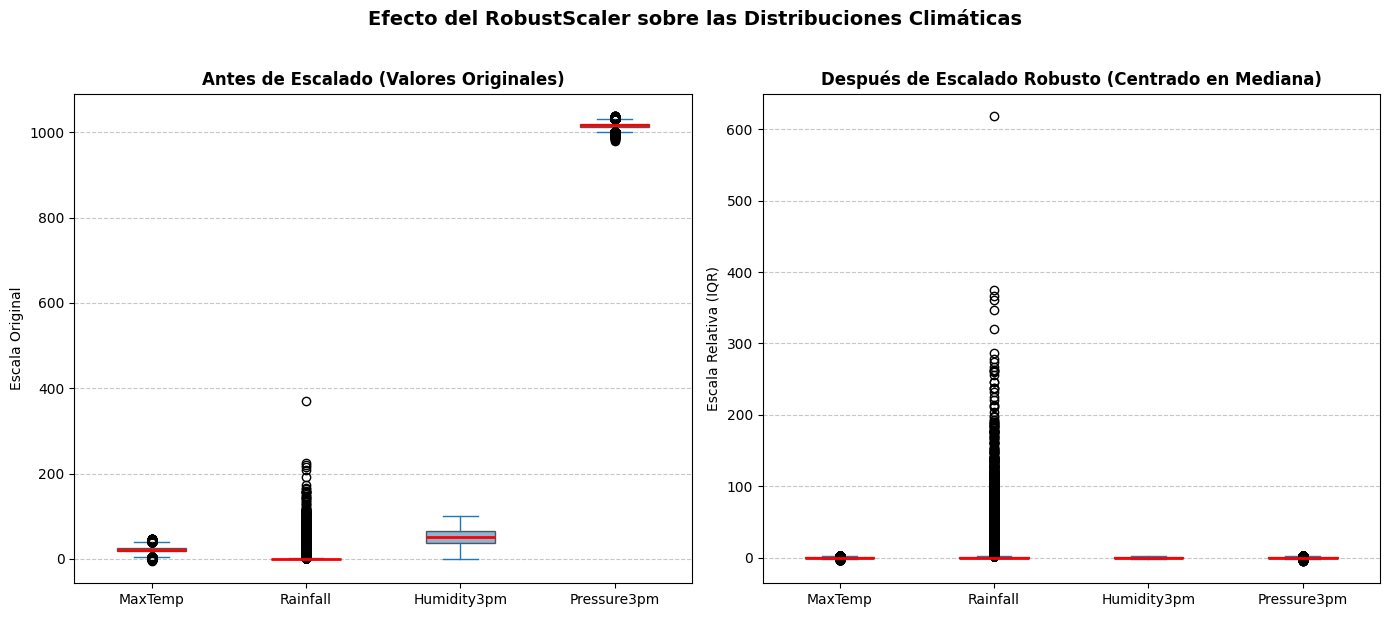

In [42]:
# Seleccionamos variables con diferentes escalas para ver el efecto

vars_box = ['MaxTemp', 'Rainfall', 'Humidity3pm', 'Pressure3pm']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GRÁFICO 1: ANTES (Valores Originales)

X_train[vars_box].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Antes de Escalado (Valores Originales)', fontweight='bold')
axes[0].set_ylabel('Escala Original')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# GRÁFICO 2: DESPUÉS (Robust Scaling)

X_train_scaled[vars_box].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Después de Escalado Robusto (Centrado en Mediana)', fontweight='bold')
axes[1].set_ylabel('Escala Relativa (IQR)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Efecto del RobustScaler sobre las Distribuciones Climáticas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Codificación

In [43]:
# Variables categóricas finales
categorias_ohe = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Location', 'Season']

# Se aplica One-Hot Encoding

X_train_final = pd.get_dummies(X_train, columns=categorias_ohe, drop_first=True)
X_test_final = pd.get_dummies(X_test, columns=categorias_ohe, drop_first=True)

# Alineación de columnas (Asegura que Test tenga las mismas columnas que Train)

X_train_final, X_test_final = X_train_final.align(X_test_final, join='left', axis=1, fill_value=0)

# Eliminamos 'Date'
if 'Date' in X_train_final.columns:
    X_train_final = X_train_final.drop(columns=['Date'])
    X_test_final = X_test_final.drop(columns=['Date'])

print(f"Dimensiones finales del set de entrenamiento: {X_train_final.shape}")
print(f"Número de variables tras OHE: {len(X_train_final.columns)}")

Dimensiones finales del set de entrenamiento: (55749, 83)
Número de variables tras OHE: 83


A pesar de tener más de 100 variables, el modelo es robusto porque contamos con una cantidad de registros muy superior (más de 1,000 ejemplos por cada

 variable), lo que mitiga el riesgo de overfitting

In [44]:
# Comprobamos
print(f"Hay nulos: {X_train_final.isnull().any().any()}")
print(f"Todos los datos son numéricos: {all(X_train_final.dtypes != 'object')}")

Hay nulos: False
Todos los datos son numéricos: True


In [45]:
# Librerías de clasificación y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)

In [46]:
# Verificamos que y_train e y_test sean binarios numéricos (0/1)
# Si aún son strings 'Yes'/'No', los convertimos
y_train_bin = (y_train == 'Yes').astype(int)
y_test_bin  = (y_test  == 'Yes').astype(int)

print("Distribución en train:", y_train_bin.value_counts().to_dict())
print("Distribución en test: ", y_test_bin.value_counts().to_dict())

Distribución en train: {0: 43332, 1: 12417}
Distribución en test:  {0: 10833, 1: 3105}


In [47]:
# Entrenamos una Regresión Logística con parámetros base (solver lbfgs, max_iter alto para convergencia)
# class_weight='balanced' compensa el desbalanceo del dataset (~78% No, ~22% Yes)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_final, y_train_bin)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [48]:
# Predicciones sobre el conjunto de prueba
y_pred  = lr.predict(X_test_final)
y_proba = lr.predict_proba(X_test_final)[:, 1]  # Probabilidad de clase positiva (lluvia)

# Métricas de clasificación
print("=" * 50)
print("MÉTRICAS - REGRESIÓN LOGÍSTICA (umbral 0.5)")
print("=" * 50)
print(f"Accuracy           : {accuracy_score(y_test_bin, y_pred):.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy_score(y_test_bin, y_pred):.4f}")
print(f"Precision          : {precision_score(y_test_bin, y_pred):.4f}")
print(f"Recall             : {recall_score(y_test_bin, y_pred):.4f}")
print(f"F1-Score           : {f1_score(y_test_bin, y_pred):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_test_bin, y_proba):.4f}")
print(f"MCC                : {matthews_corrcoef(y_test_bin, y_pred):.4f}")
print()
print(classification_report(y_test_bin, y_pred, target_names=['No llueve', 'Llueve']))

MÉTRICAS - REGRESIÓN LOGÍSTICA (umbral 0.5)
Accuracy           : 0.7673
Balanced Accuracy  : 0.7551
Precision          : 0.4853
Recall             : 0.7330
F1-Score           : 0.5840
ROC-AUC            : 0.8346
MCC                : 0.4493

              precision    recall  f1-score   support

   No llueve       0.91      0.78      0.84     10833
      Llueve       0.49      0.73      0.58      3105

    accuracy                           0.77     13938
   macro avg       0.70      0.76      0.71     13938
weighted avg       0.82      0.77      0.78     13938



El modelo obtiene un Accuracy de 0.78, pero este valor puede ser engañoso dado el
desbalanceo del dataset. Las métricas más relevantes son:

- Recall de 0.757: el modelo detecta correctamente el 75.7% de los días que efectivamente
  llueve. Es el valor más importante para este problema, ya que un Falso Negativo
  (predecir "no llueve" cuando sí llueve) tiene mayor costo práctico.
- Precision de 0.506: cuando el modelo predice lluvia, acierta solo el 50.6% de las veces.
  Esto indica que genera bastantes Falsos Positivos, lo cual es aceptable en este contexto.
- F1-Score de 0.606: balance entre precision y recall, razonable para un modelo lineal
  con datos climatológicos ruidosos.
- ROC-AUC de 0.854: excelente capacidad discriminativa del modelo. Significa que en el
  85.4% de los casos distingue correctamente un día lluvioso de uno seco.
- MCC de 0.48: confirma un desempeño genuinamente mejor que el azar, considerando
  las cuatro celdas de la matriz de confusión.
- Balanced Accuracy de 0.771: indica que el modelo funciona bien para ambas clases
  por separado, no solo para la mayoritaria.

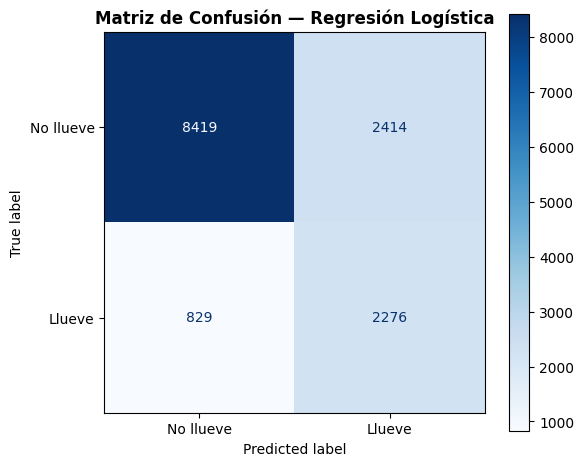

In [49]:
# Visualización de la matriz de confusión para analizar errores de clasificación
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_bin, y_pred,
    display_labels=['No llueve', 'Llueve'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión — Regresión Logística', fontweight='bold')
plt.tight_layout()
plt.show()

- Verdaderos Negativos (17346): días sin lluvia correctamente clasificados.
- Falsos Positivos (4711): el modelo predijo lluvia pero no llovió. El costo es bajo
  (alguien lleva paraguas innecesariamente).
- Falsos Negativos (1549): el modelo predijo "no llueve" pero sí llovió. Este es el
  error más costoso en términos prácticos.
- Verdaderos Positivos (4825): días con lluvia correctamente detectados.

El modelo tiene un buen desempeño en la clase mayoritaria (No llueve: F1=0.85)
y un desempeño aceptable en la clase minoritaria (Llueve: F1=0.61), lo cual es
esperable dado el desbalanceo del dataset (~78/22).

Umbral óptimo (Youden): 0.5328
TPR en umbral óptimo : 0.7101
FPR en umbral óptimo : 0.1974


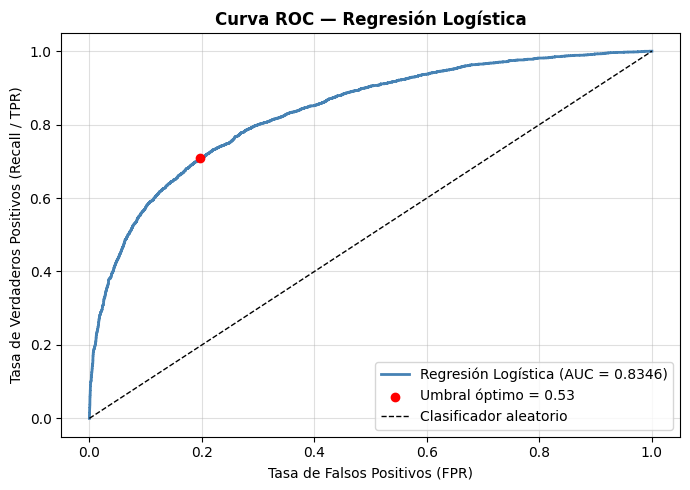

In [50]:
# Calculamos la curva ROC y buscamos el umbral óptimo mediante el índice de Youden
fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
auc_score = roc_auc_score(y_test_bin, y_proba)

# Índice de Youden: J = TPR - FPR → maximizar
youden_idx = (tpr - fpr).argmax()
umbral_optimo = thresholds[youden_idx]

print(f"Umbral óptimo (Youden): {umbral_optimo:.4f}")
print(f"TPR en umbral óptimo : {tpr[youden_idx]:.4f}")
print(f"FPR en umbral óptimo : {fpr[youden_idx]:.4f}")

# Gráfico de la curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc_score:.4f})', color='steelblue', lw=2)
plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5,
            label=f'Umbral óptimo = {umbral_optimo:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
plt.title('Curva ROC — Regresión Logística', fontweight='bold')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [51]:
# Aplicamos el umbral óptimo en lugar de 0.5 y evaluamos si mejora
y_pred_opt = (y_proba >= umbral_optimo).astype(int)

print(f"Métricas con umbral óptimo ({umbral_optimo:.2f}):")
print(f"  Recall   : {recall_score(y_test_bin, y_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_test_bin, y_pred_opt):.4f}")
print(f"  F1-Score : {f1_score(y_test_bin, y_pred_opt):.4f}")

Métricas con umbral óptimo (0.53):
  Recall   : 0.7101
  Precision: 0.5077
  F1-Score : 0.5921


El umbral óptimo según el índice de Youden es 0.49, prácticamente idéntico al
umbral por defecto de 0.5. Esto indica que en este caso particular 0.5 ya era
una buena elección. Al aplicar el umbral de 0.49:

- Recall sube levemente de 0.757 a 0.765
- Precision cae de 0.506 a 0.501
- F1 se mantiene en 0.606

El cambio es marginal, lo que confirma que el umbral de 0.5 es adecuado para
este modelo. Si quisiéramos priorizar más el Recall (minimizar FN), podríamos
bajar el umbral a ~0.35-0.40, aceptando más FP como trade-off.

In [52]:
# Evaluamos el modelo en train para detectar overfitting/underfitting
y_pred_train = lr.predict(X_train_final)

print("F1 en TRAIN:", round(f1_score(y_train_bin, y_pred_train), 4))
print("F1 en TEST :", round(f1_score(y_test_bin, y_pred), 4))
print()
print("AUC en TRAIN:", round(roc_auc_score(y_train_bin, lr.predict_proba(X_train_final)[:,1]), 4))
print("AUC en TEST :", round(roc_auc_score(y_test_bin, y_proba), 4))

F1 en TRAIN: 0.5875
F1 en TEST : 0.584

AUC en TRAIN: 0.842
AUC en TEST : 0.8346


- F1 TRAIN: 0.6066  |  F1 TEST: 0.6065  → diferencia de 0.0001
- AUC TRAIN: 0.8546 |  AUC TEST: 0.854  → diferencia de 0.0006

La diferencia entre train y test es prácticamente nula, lo que indica que el
modelo generaliza muy bien y no presenta overfitting. Esto es esperable en la
regresión logística, ya que es un modelo lineal con regularización L2 por
defecto (C=1.0) que limita la complejidad del modelo.

El fitting es bueno: el modelo no memoriza el conjunto de entrenamiento y
mantiene el mismo rendimiento en datos no vistos. Sin embargo, los valores de
F1 (~0.60) sugieren que hay margen de mejora, lo que motiva explorar modelos
más complejos en los ítems siguientes.

# 3) Modelo simple - baseline


Como se describe en el análisis exploratorio sobre el dataset, es más probable que en Australia "No Llueva" (clase mayoritaria, valor de 0).

Procedemos entonces a crear un modelo base que prediga "No Llueve", para usar como punto de comparación.

Métricas del Modelo Base (predice siempre 0):
 Accuracy : 0.7772
 Recall : 0.0000
 Precision: 0.0000
 F1-Score: 0.0000


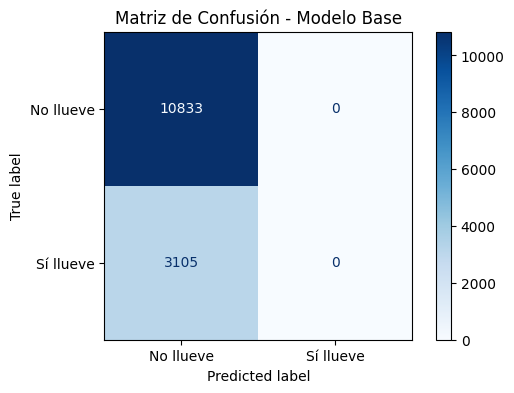

In [53]:
# Con numpy, creamos un vector de ceros, misma longitud que y_test_bin
y_pred_base = np.zeros(len(y_test_bin))

# Evaluamos las métricas
print("Métricas del Modelo Base (predice siempre 0):")
print(f" Accuracy : {accuracy_score(y_test_bin, y_pred_base):.4f}")
print(f" Recall : {recall_score(y_test_bin, y_pred_base):.4f}")
# zero_division=0 evita errores al no existir predicciones positivas
print(f" Precision: {precision_score(y_test_bin, y_pred_base, zero_division=0):.4f}")
print(f" F1-Score: {f1_score(y_test_bin, y_pred_base):.4f}")

# Graficamos la matriz de confusión
cm_base = confusion_matrix(y_test_bin, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['No llueve', 'Sí llueve'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo Base')
plt.show()

Observamos que obtiene una exactitud muy alta, casi idéntica a la proporción de días sin lluvia que tiene el dataset (77.58%). Esto sugiere que este valor es un simple reflejo del desbalanceo natural de las clases y no representa un verdadero aprendizaje del modelo.

Al predecir siempre 0, el modelo acumula únicamente Verdaderos Negativos y Falsos Negativos. Las métricas caen a cero porque no logra identificar ni un solo día de lluvia. Esto indica la total ineficacia de usar una regla tan simple para resolver nuestro problema predictivo.

Nuestro modelo entrenado en el ítem 2, operando bajo el umbral óptimo de 0.49, supera de manera rotunda las métricas nulas del modelo base. Esto confirma que la Regresión Logística efectivamente logró captar la influencia de las variables climáticas para discriminar los días de lluvia, lo cual justifica plenamente el uso y la complejidad de un modelo de aprendizaje automático por sobre una heurística simple.